## Week Eight - Assignment High Frequency Words

Brandon Chung 3/28/2026

## Instructions

1. Choose a corpus of interest. 
2. How many total unique words are in the corpus?  (Please feel free to define unique words in any interesting defensible way). 
3. Taking the most common words, how many unique words represent half of the total words in the corpus? 
4. Identify the 200 highest frequency words in this corpus. 
5. Create a graph that shows the relative frequency of these 200 words. 
6. Does the observed relative frequency of these words follow Zipf’s law?  Explain. 
7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.” 

## Introduction

For this assignment I have choosen a transcript of President Donald Trump's 2025 Inaugural Address Speech as found on the White House website here: https://www.whitehouse.gov/remarks/2025/01/the-inaugural-address/ 

In [16]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the text
corpus_text = """[Thank you.  Thank you very much, everybody.  (Applause.)  Wow.  Thank you very, very much.

Vice President Vance, Speaker Johnson, Senator Thune, Chief Justice Roberts, justices of the Supreme Court of the United States, President Clinton, President Bush, President Obama, President Biden, Vice President Harris, and my fellow citizens, the golden age of America begins right now.  (Applause.)  
 
From this day forward, our country will flourish and be respected again all over the world.  We will be the envy of every nation, and we will not allow ourselves to be taken advantage of any longer.  During every single day of the Trump administration, I will, very simply, put America first.  (Applause.) 
 
Our sovereignty will be reclaimed.  Our safety will be restored.  The scales of justice will be rebalanced.  The vicious, violent, and unfair weaponization of the Justice Department and our government will end.  (Applause.)  
 
And our top priority will be to create a nation that is proud, prosperous, and free.  (Applause.)

America will soon be greater, stronger, and far more exceptional than ever before.  (Applause.) 
 
I return to the presidency confident and optimistic that we are at the start of a thrilling new era of national success.  A tide of change is sweeping the country, sunlight is pouring over the entire world, and America has the chance to seize this opportunity like never before.  
 
But first, we must be honest about the challenges we face.  While they are plentiful, they will be annihilated by this great momentum that the world is now witnessing in the United States of America. 
 
As we gather today, our government confronts a crisis of trust.  For many years, a radical and corrupt establishment has extracted power and wealth from our citizens while the pillars of our society lay broken and seemingly in complete disrepair.  
 
We now have a government that cannot manage even a simple crisis at home while, at the same time, stumbling into a continuing catalogue of catastrophic events abroad. 
 
It fails to protect our magnificent, law-abiding American citizens but provides sanctuary and protection for dangerous criminals, many from prisons and mental institutions, that have illegally entered our country from all over the world.  
 
We have a government that has given unlimited funding to the defense of foreign borders but refuses to defend American borders or, more importantly, its own people. 
 
Our country can no longer deliver basic services in times of emergency, as recently shown by the wonderful people of North Carolina — who have been treated so badly — (applause) — and other states who are still suffering from a hurricane that took place many months ago or, more recently, Los Angeles, where we are watching fires still tragically burn from weeks ago without even a token of defense.  They’re raging through the houses and communities, even affecting some of the wealthiest and most powerful individuals in our country — some of whom are sitting here right now.  They don’t have a home any longer.  That’s interesting.  But we can’t let this happen.  Everyone is unable to do anything about it.  That’s going to change. 
 
We have a public health system that does not deliver in times of disaster, yet more money is spent on it than any country anywhere in the world.  

And we have an education system that teaches our children to be ashamed of themselves — in many cases, to hate our country despite the love that we try so desperately to provide to them.  All of this will change starting today, and it will change very quickly.  (Applause.)
 
My recent election is a mandate to completely and totally reverse a horrible betrayal and all of these many betrayals that have taken place and to give the people back their faith, their wealth, their democracy, and, indeed, their freedom.  From this moment on, America’s decline is over.  (Applause.)
 
Our liberties and our nation’s glorious destiny will no longer be denied.  And we will immediately restore the integrity, competency, and loyalty of America’s government. 
 
Over the past eight years, I have been tested and challenged more than any president in our 250-year history, and I’ve learned a lot along the way. 
 
The journey to reclaim our republic has not been an easy one — that, I can tell you.  Those who wish to stop our cause have tried to take my freedom and, indeed, to take my life. 
 
Just a few months ago, in a beautiful Pennsylvania field, an assassin’s bullet ripped through my ear.  But I felt then and believe even more so now that my life was saved for a reason.  I was saved by God to make America great again.  (Applause.)
 
Thank you.  Thank you.  (Applause.)

Thank you very much.  (Applause.)
 
That is why each day under our administration of American patriots, we will be working to meet every crisis with dignity and power and strength.  We will move with purpose and speed to bring back hope, prosperity, safety, and peace for citizens of every race, religion, color, and creed. 
 
For American citizens, January 20th, 2025, is Liberation Day.  (Applause.)  It is my hope that our recent presidential election will be remembered as the greatest and most consequential election in the history of our country.  
 
As our victory showed, the entire nation is rapidly unifying behind our agenda with dramatic increases in support from virtually every element of our society: young and old, men and women, African Americans, Hispanic Americans, Asian Americans, urban, suburban, rural.  And very importantly, we had a powerful win in all seven swing states — (applause) — and the popular vote, we won by millions of people.  (Applause.) 

To the Black and Hispanic communities, I want to thank you for the tremendous outpouring of love and trust that you have shown me with your vote.  We set records, and I will not forget it.  I’ve heard your voices in the campaign, and I look forward to working with you in the years to come. 
 
Today is Martin Luther King Day.  And his honor — this will be a great honor.  But in his honor, we will strive together to make his dream a reality.  We will make his dream come true.  (Applause.)
 
Thank you.  Thank you.  Thank you.  (Applause.)
 
National unity is now returning to America, and confidence and pride is soaring like never before.  In everything we do, my administration will be inspired by a strong pursuit of excellence and unrelenting success.  We will not forget our country, we will not forget our Constitution, and we will not forget our God.  Can’t do that.  (Applause.)
 
Today, I will sign a series of historic executive orders.  With these actions, we will begin the complete restoration of America and the revolution of common sense.  It’s all about common sense.  (Applause.)
 
First, I will declare a national emergency at our southern border.  (Applause.)
 
All illegal entry will immediately be halted, and we will begin the process of returning millions and millions of criminal aliens back to the places from which they came.  We will reinstate my Remain in Mexico policy.  (Applause.)
 
I will end the practice of catch and release.  (Applause.)
 
And I will send troops to the southern border to repel the disastrous invasion of our country.  (Applause.)
 
Under the orders I sign today, we will also be designating the cartels as foreign terrorist organizations.  (Applause.)
 
And by invoking the Alien Enemies Act of 1798, I will direct our government to use the full and immense power of federal and state law enforcement to eliminate the presence of all foreign gangs and criminal networks bringing devastating crime to U.S. soil, including our cities and inner cities.  (Applause.) 
 
As commander in chief, I have no higher responsibility than to defend our country from threats and invasions, and that is exactly what I am going to do.  We will do it at a level that nobody has ever seen before.
 
Next, I will direct all members of my cabinet to marshal the vast powers at their disposal to defeat what was record inflation and rapidly bring down costs and prices.  (Applause.) 
 
The inflation crisis was caused by massive overspending and escalating energy prices, and that is why today I will also declare a national energy emergency.  We will drill, baby, drill.  (Applause.)
 
America will be a manufacturing nation once again, and we have something that no other manufacturing nation will ever have — the largest amount of oil and gas of any country on earth — and we are going to use it.  We’ll use it.  (Applause.)
 
We will bring prices down, fill our strategic reserves up again right to the top, and export American energy all over the world.  (Applause.) 
 
We will be a rich nation again, and it is that liquid gold under our feet that will help to do it. 
 
With my actions today, we will end the Green New Deal, and we will revoke the electric vehicle mandate, saving our auto industry and keeping my sacred pledge to our great American autoworkers.  (Applause.)
 
In other words, you’ll be able to buy the car of your choice.
 
We will build automobiles in America again at a rate that nobody could have dreamt possible just a few years ago.  And thank you to the autoworkers of our nation for your inspiring vote of confidence.  We did tremendously with their vote.  (Applause.)  
 
I will immediately begin the overhaul of our trade system to protect American workers and families.  Instead of taxing our citizens to enrich other countries, we will tariff and tax foreign countries to enrich our citizens.  (Applause.)
 
For this purpose, we are establishing the External Revenue Service to collect all tariffs, duties, and revenues.  It will be massive amounts of money pouring into our Treasury, coming from foreign sources. 
 
The American dream will soon be back and thriving like never before.  

To restore competence and effectiveness to our federal government, my administration will establish the brand-new Department of Government Efficiency.  (Applause.)
 
After years and years of illegal and unconstitutional federal efforts to restrict free expression, I also will sign an executive order to immediately stop all government censorship and bring back free speech to America.  (Applause.)
 
Never again will the immense power of the state be weaponized to persecute political opponents — something I know something about.  (Laughter.)  We will not allow that to happen.  It will not happen again.
 
Under my leadership, we will restore fair, equal, and impartial justice under the constitutional rule of law.  (Applause.)
 
And we are going to bring law and order back to our cities.  (Applause.) 
 
This week, I will also end the government policy of trying to socially engineer race and gender into every aspect of public and private life.  (Applause.)  We will forge a society that is colorblind and merit-based.  (Applause.)  
 
As of today, it will henceforth be the official policy of the United States government that there are only two genders: male and female.  (Applause.)
 
This week, I will reinstate any service members who were unjustly expelled from our military for objecting to the COVID vaccine mandate with full back pay.  (Applause.)
 
And I will sign an order to stop our warriors from being subjected to radical political theories and social experiments while on duty.  It’s going to end immediately.  (Applause.)  Our armed forces will be freed to focus on their sole mission: defeating America’s enemies.  (Applause.)
 
Like in 2017, we will again build the strongest military the world has ever seen.  We will measure our success not only by the battles we win but also by the wars that we end — and perhaps most importantly, the wars we never get into.  (Applause.)  
 
My proudest legacy will be that of a peacemaker and unifier.  That’s what I want to be: a peacemaker and a unifier.
 
I’m pleased to say that as of yesterday, one day before I assumed office, the hostages in the Middle East are coming back home to their families.  (Applause.)
 
Thank you.
 
America will reclaim its rightful place as the greatest, most powerful, most respected nation on earth, inspiring the awe and admiration of the entire world. 
 
A short time from now, we are going to be changing the name of the Gulf of Mexico to the Gulf of America — (applause) — and we will restore the name of a great president, William McKinley, to Mount McKinley, where it should be and where it belongs.  (Applause.)
 
President McKinley made our country very rich through tariffs and through talent — he was a natural businessman — and gave Teddy Roosevelt the money for many of the great things he did, including the Panama Canal, which has foolishly been given to the country of Panama after the United Spates — the United States — I mean, think of this — spent more money than ever spent on a project before and lost 38,000 lives in the building of the Panama Canal. 
 
We have been treated very badly from this foolish gift that should have never been made, and Panama’s promise to us has been broken. 
 
The purpose of our deal and the spirit of our treaty has been totally violated.  American ships are being severely overcharged and not treated fairly in any way, shape, or form.  And that includes the United States Navy.
 
And above all, China is operating the Panama Canal.  And we didn’t give it to China.  We gave it to Panama, and we’re taking it back.  (Applause.)
 
Above all, my message to Americans today is that it is time for us to once again act with courage, vigor, and the vitality of history’s greatest civilization. 
 
So, as we liberate our nation, we will lead it to new heights of victory and success.  We will not be deterred.  Together, we will end the chronic disease epidemic and keep our children safe, healthy, and disease-free.  
 
The United States will once again consider itself a growing nation — one that increases our wealth, expands our territory, builds our cities, raises our expectations, and carries our flag into new and beautiful horizons.  
 
And we will pursue our manifest destiny into the stars, launching American astronauts to plant the Stars and Stripes on the planet Mars.  (Applause.)
 
Ambition is the lifeblood of a great nation, and, right now, our nation is more ambitious than any other.  There’s no nation like our nation.
 
Americans are explorers, builders, innovators, entrepreneurs, and pioneers.  The spirit of the frontier is written into our hearts.  The call of the next great adventure resounds from within our souls. 
 
Our American ancestors turned a small group of colonies on the edge of a vast continent into a mighty republic of the most extraordinary citizens on Earth.  No one comes close.
 
Americans pushed thousands of miles through a rugged land of untamed wilderness.  They crossed deserts, scaled mountains, braved untold dangers, won the Wild West, ended slavery, rescued millions from tyranny, lifted billions from poverty, harnessed electricity, split the atom, launched mankind into the heavens, and put the universe of human knowledge into the palm of the human hand.  If we work together, there is nothing we cannot do and no dream we cannot achieve.  
 
Many people thought it was impossible for me to stage such a historic political comeback.  But as you see today, here I am.  The American people have spoken.  (Applause.)
 
I stand before you now as proof that you should never believe that something is impossible to do.  In America, the impossible is what we do best.  (Applause.)
 
From New York to Los Angeles, from Philadelphia to Phoenix, from Chicago to Miami, from Houston to right here in Washington, D.C., our country was forged and built by the generations of patriots who gave everything they had for our rights and for our freedom.  
 
They were farmers and soldiers, cowboys and factory workers, steelworkers and coal miners, police officers and pioneers who pushed onward, marched forward, and let no obstacle defeat their spirit or their pride.  
 
Together, they laid down the railroads, raised up the skyscrapers, built great highways, won two world wars, defeated fascism and communism, and triumphed over every single challenge that they faced. 
 
After all we have been through together, we stand on the verge of the four greatest years in American history.  With your help, we will restore America promise and we will rebuild the nation that we love — and we love it so much.  
 
We are one people, one family, and one glorious nation under God.  So, to every parent who dreams for their child and every child who dreams for their future, I am with you, I will fight for you, and I will win for you.  We’re going to win like never before.  (Applause.)
 
Thank you.  Thank you.  (Applause.)

Thank you.  Thank you.  (Applause.)

In recent years, our nation has suffered greatly. But we are going to bring it back and make it great again, greater than ever before. 
 
We will be a nation like no other, full of compassion, courage, and exceptionalism.  Our power will stop all wars and bring a new spirit of unity to a world that has been angry, violent, and totally unpredictable. 
 
America will be respected again and admired again, including by people of religion, faith, and goodwill.  We will be prosperous, we will be proud, we will be strong, and we will win like never before. 
 
We will not be conquered, we will not be intimidated, we will not be broken, and we will not fail.  From this day on, the United States of America will be a free, sovereign, and independent nation. 
 
We will stand bravely, we will live proudly, we will dream boldly, and nothing will stand in our way because we are Americans.  The future is ours, and our golden age has just begun. 
 
Thank you.  God bless America.  Thank you all.  Thank you.  (Applause.)  Thank you very much.  Thank you very much.  Thank you.  (Applause.)  

Thank you.  (Applause.)]"""



In [17]:
# Preprocesseing the text 

# Remove (Applause), (Laughter), and punctuation
clean_text = re.sub(r'\(.*?\)', '', corpus_text) # Remove parentheses and content
tokens = re.findall(r'\b\w+\b', clean_text.lower())

# Count unique words
word_counts = Counter(tokens)
total_tokens = len(tokens)
unique_words = len(word_counts)

print(f"Total Word Tokens: {total_tokens}")
print(f"Total Unique Words: {unique_words}")

Total Word Tokens: 2942
Total Unique Words: 937


After loading the text I am using regular expressions to preprocess. I am removing the audiance's actions (applause and laughter), which is contained in parentheses in the transcript, then also removing "word boundaries" such as commas, period, and dashes, and making all words lowercase for standardization. 

In the Trump's address there are 937 total unique words and 2942 total words.

In [18]:
# Sort words by frequency
sorted_words = word_counts.most_common()

# Initialize count and number of words needed to reach 50% of the corpus
cumulative_count = 0
words_for_half = 0

for word, freq in sorted_words:
    cumulative_count += freq
    words_for_half += 1
    if cumulative_count >= total_tokens / 2:
        break

print(f"It takes {words_for_half} unique words to represent 50% of the corpus.")

It takes 52 unique words to represent 50% of the corpus.


Using most_common() I sorted the dictonary from highest frequency words to lowest then fed that into a for loop while adding the frequency to a running total - stopping when that running total hits 50% of the total words in the speech. I found that it takes 52 unique words to represent half of the total words. 

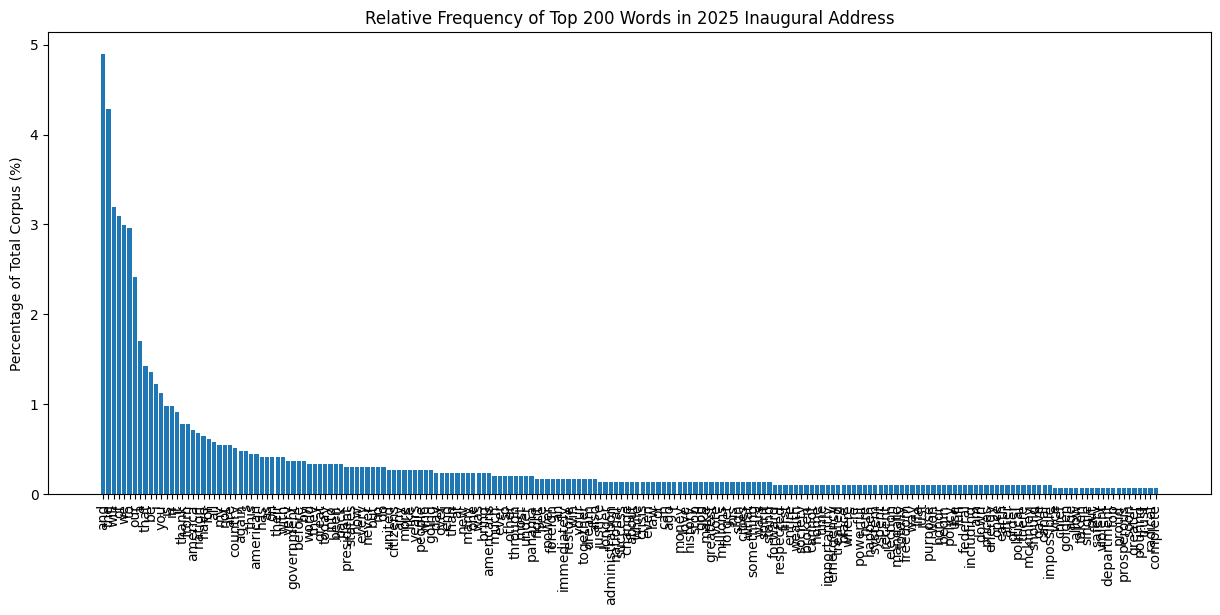

['and', 'the', 'will', 'of', 'we', 'to', 'our', 'a', 'that', 'be', 'i', 'you', 'is', 'in', 'it', 'thank', 'from', 'america', 'nation', 'have', 'for', 'all', 'my', 'not', 'are', 'country', 'again', 's', 'this', 'american', 'has', 'as', 'on', 'their', 'with', 'very', 'government', 'before', 'by', 'world', 'they', 'great', 'today', 'into', 'been', 'back', 'president', 'states', 'now', 'every', 'never', 'but', 'no', 'do', 'united', 'citizens', 'any', 'more', 'like', 'years', 'people', 'who', 'going', 'day', 'over', 'end', 'than', 'at', 'new', 'many', 'one', 'was', 'bring', 'americans', 'much', 'ever', 'so', 'other', 'through', 'most', 'under', 'panama', 'right', 'free', 'power', 'foreign', 'an', 'immediately', 'restore', 'win', 'your', 'together', 'dream', 'also', 'justice', 'longer', 'administration', 'national', 'success', 'change', 'about', 'while', 'crisis', 'even', 'law', 'or', 'can', 'ago', 't', 'money', 'love', 'history', 'stop', 'god', 'make', 'greatest', 'vote', 'millions', 'forge

In [19]:
# Identify the 200 highest frequency words
top_200 = sorted_words[:200]
df = pd.DataFrame(top_200, columns=['Word', 'Frequency'])
df['Relative Frequency (%)'] = (df['Frequency'] / total_tokens) * 100

# Create graph
plt.figure(figsize=(15, 6))
plt.bar(df['Word'][:200], df['Relative Frequency (%)'][:200])
plt.xticks(rotation=90)
plt.title("Relative Frequency of Top 200 Words in 2025 Inaugural Address")
plt.ylabel("Percentage of Total Corpus (%)")
plt.show()

# Printing list of 200 highest frequency words
print(df['Word'].head(200).to_list())

# Printing top 20 list
print(df.head(20))

The observed frequency of the top 200 words from the speech follows Zipf's law. The frequency of the words drops very sharply and flattens out to a long low tail. This corpus of text however does deviate from Zipf's law by displaying the first 7 or so words with similar height. This could be due to the speaking style of Trump or because political speeches are purposely repetitive and message driven. 

Compared to "all words in all corpora" this corpus differs significantly in usage of certain word themes. Based on our findings of the highest frequency words this speech focuses on "we" and "our" to create a sense of unity. This corpus also is a political speech and so when compared to universal corpora this corpus has increased use of persuasive or declaritive vocabulary such as "will", as well as topical "spikes". The speech covers "borders", "tariffs", and "energy" in higher frequency than all corpora. 

Video Presentation: https://youtu.be/IEcAcDOOaGc